In [9]:
import numpy as np
import pandas as pd
import cvxopt
import scipy.stats as ss
from scipy.linalg import expm
from scipy.linalg import solve
import scipy.optimize as optim
import scipy.interpolate as si
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.integrate import odeint
import datetime as dt
import glob
import seaborn as sns
import numdifftools as numdif
import statsmodels.api as sm
import pandas as pd
import statsmodels.nonparametric.kernel_regression as kernelreg
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from matplotlib.pyplot import (figure, axes, plot, xlabel, ylabel, title,grid, show)
import pickle
import csaps
import gzip
from datetime import datetime, timedelta
from os import path
import os
import sys
import requests
import zipfile
from io import StringIO
import json
import copy
import time
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
from sklearn.linear_model import LinearRegression

In [2]:
#experimental data
df = pd.read_csv(r'C:\Users\albyg\Desktop\thesis\borgerskolen_experiment.csv',  usecols = ['time', 'Ta', 'Room_C0.01_Temperature__icmeter','Room_C1.00_Temperature__elsys','Ps', 'Tset_minus_Ti_C0.01', "Tset_C0.01", "Tfor_minus_Ti_C0.01"])
df1=pd.read_csv(r'C:\Users\albyg\Desktop\thesis\TemperaturePIcontroller.csv')
df2=pd.read_csv(r'C:\Users\albyg\Desktop\thesis\TemperatureC001.csv')
df2['time']=(df1['time'])

#experimental temperature
Yexp=np.array(df['Room_C0.01_Temperature__icmeter'].tolist())

# simulated data
df2=df2.drop_duplicates(subset=['time'])
df2=df2.reset_index()

# simulated temperature
sim_temp=df2['zoneR1C1_AG_slower.Y']
sim_temp=np.array(sim_temp)
Y=sim_temp

# T_for-T_room
X=df['Tfor_minus_Ti_C0.01']
X=X.iloc[:-1]

# T_set-T_room
U1=df['Tset_C0.01']-df['Room_C0.01_Temperature__icmeter']
U1=np.array(U1.iloc[:-1].tolist())

# T_ambient-T_room
U2=df["Ta"]-df['Room_C0.01_Temperature__icmeter']
U2=np.array(U2.iloc[:-1].tolist())

# solar radiations
U3=np.array(df['Ps'].iloc[:-1].tolist()) #solar power

# Y1
Y1=np.zeros(X.size)
Y1[0]=Y[0]

# U1
U1pred=np.zeros((len(Y),1))
U1pred[1]=U1[1]

## Tset
Tset=df['Tset_C0.01']
Tset=np.array(Tset.iloc[:-1].tolist())

# Ta
Ta=df['Ta']
Ta=np.array(Ta.iloc[:-1].tolist())

# Ti
Ti=df2['zoneR1C1_AG_slower.Y']
Ti=np.array(Ti.iloc[:-1].tolist())

# T_for
Tfor=X+Ti

# noise 
#m=1294
m=1295
epsvar = 0.1
eps = np.random.normal(0,np.sqrt(epsvar),m) # i.i.d. normal random noise
np.random.seed(12357841)
Y=Y+eps

In [3]:
def construct_bspline_basisfunctions_and_knot_placements(x0,x1,nx=48,bspline_order=4, knot_params=None, return_t=False):
    _nt = bspline_order
    x = np.linspace(x0,x1,nx)
    y = np.ones((x.shape)) # the function we wish to interpolate
    if knot_params is None:
        t = np.linspace(x[0],x[-1],_nt)
        t = t[1:-1]
    else:
        t = np.cumsum(knot_params)
        
    tt = np.linspace(x0, x1, nx)
    y_rep = si.splrep(x, y, t=t, k=3)

    bsplines = np.zeros((nx,_nt+2))

    for i in range(_nt+2):
        vec = np.zeros(_nt+2)
        vec[i] = 1.0
        y_list = list(y_rep)
        y_list[1] = vec.tolist()
        y_i = si.splev(tt, y_list) # your basis spline function
        bsplines[:,i] = y_i
    if return_t:
        return bsplines, tt
    else:
        return bsplines

In [4]:
Bsplines = construct_bspline_basisfunctions_and_knot_placements(0,24,nx=48,bspline_order=2)

In [5]:
# estimation linear parameters

D = np.array([Y[:-1], X]).T # design matrix
thetahat = solve(D.T@D, D.T@Y[1:]) # least sqaures parameter estimate

In [6]:
## optimization non-linear parameters

## Define the objective function
def f_estimate(_theta, _U1, _X, _Y, _U2, _U3):
    _alpha, _gamma = _theta[0:2]
    _alpha_splines = np.array(_theta[2:]).reshape((4,1))
    _solar =Bsplines@_alpha_splines
    _solar=np.repeat(_solar,U3.size/48+1)[:-2]
    _Ud = 1/(1+np.exp(-_alpha*(_U1+_gamma)))    
    _D = np.array([_Y[:-1], _Ud*_X, _U2, _solar*_U3]).T # design matrix
    _theta_reg = solve(_D.T@_D, _D.T@_Y[1:])   
    return _theta_reg, _D

# Sum of square errors
def f(_theta, _U1, _X, _Y, _U2, _U3):
    _thetahat, _D=f_estimate(_theta, _U1, _X, _Y, _U2, _U3)
    predictions=_D@_thetahat
    _S = (_Y[1:] - predictions).T@(_Y[1:] - predictions)
    return _S

In [12]:
theta_zero=[1,0,1,1,1,1]
bounds = ((-4,4),(-4,4),(-4,4),(-4,4),(-4,4),(-4,4))
# Start the timer
start_time = time.time()





# Print the result and computational time


res = optim.minimize(f, theta_zero, args=(U1, X, Y, U2, U3), method="SLSQP",options={"maxiter":10000, "ftol":1e-5})
# Stop the timer
end_time = time.time()

# Compute the computational time
computational_time = end_time - start_time
print("Computational time:", computational_time, "seconds")
theta_reg,D=f_estimate(res.x, U1, X, Y, U2,U3)

Computational time: 0.16157054901123047 seconds


In [8]:
## predictions with non-linear terms

Y2=np.zeros((len(Y),1))
Y2[0]=Y[0]
alpha=res.x[0]
gamma=res.x[1]

varphi1=theta_reg[0]
delta=theta_reg[1]
phi2=theta_reg[2]
phi3=theta_reg[3]

_theta=res["x"]
_alpha_splines = np.array(_theta[2:]).reshape((4,1))
_solar =Bsplines@_alpha_splines
_solar=np.repeat(_solar,U3.size/48+1)[:-2]

In [9]:
## no noise 
for i in range(0,len(X)):
    Ud = 1/(1+np.exp(-alpha*(Tset[i]-Y2[i]+gamma)))
    Y2[i+1] = varphi1*Y2[i] + delta*Ud*(Tfor[i]-Y2[i]) + phi2*(Ta[i]-Y2[i])+phi3*_solar[i]*U3[i]#+ eps[i]

## saving data
#np.save('M4_FMU_no_noise', Y2)

In [10]:
#linear parameters

#phi1=varphi1
#beta1=phi2
#beta2=delta*Ud
#beta3=phi3
print(varphi1)
print(phi2)
print(delta*Ud)
print(phi3)

0.927419501556364
0.0056483024035604915
[0.04493858]
0.048726780120212906


In [11]:
#non-linear parameters

#alpha1=alpha
#alpha2=gamma
print(alpha)
print(gamma)

-11.279396098096203
-94.02820178468062


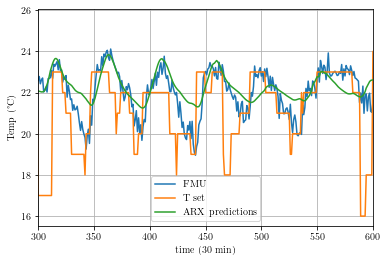

In [12]:
# Plot ZOOM ARX predictions with Tset
plt.figure(6)
plt.plot(Y, label="FMU")
plt.plot(Tset, label='T set')
plt.plot(Y2, label="ARX predictions")
plt.legend(loc="best")
xlabel(' time (30 min)')
ylabel(u'Temp (\u00B0C)')
plt.xlim(300, 600)
grid(True)
plt.savefig('M4_3.png')

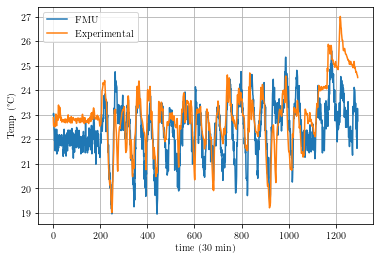

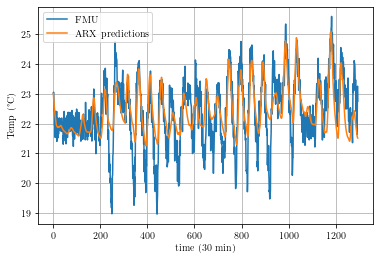

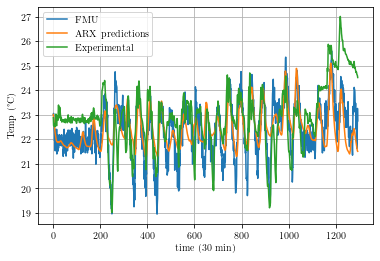

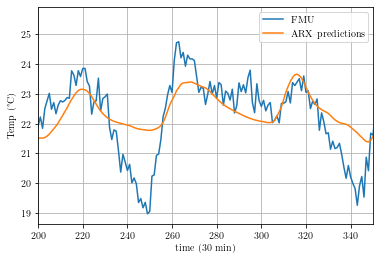

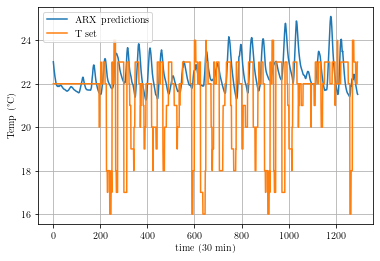

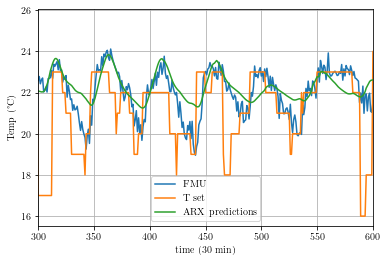

In [13]:
# FMU and Experimental

plt.figure(1)
plt.plot(Y, label="FMU")
plt.plot(Yexp, label='Experimental')
plt.legend(loc="best")
xlabel(' time (30 min)')
ylabel(u'Temp (\u00B0C)')
plt.grid()
plt.savefig("FMU_Experimental_noise.png")
plt.show()

# Plot FMU and ARX predictions based on FMU data

plt.figure(2)
plt.plot(Y, label="FMU")
plt.plot(Y2, label='ARX predictions')
plt.legend(loc="best")
xlabel(' time (30 min)')
ylabel(u'Temp (\u00B0C)')
plt.grid()
plt.savefig("FMU_ARX_M4_noise.png")
plt.show()


# Plot FMU and ARX predictions based on FMU data and experimental data
plt.figure(3)
plt.plot(Y, label="FMU")
plt.plot(Y2, label='ARX predictions')
plt.plot(Yexp, label='Experimental')
plt.legend(loc="best")
xlabel(' time (30 min)')
ylabel(u'Temp (\u00B0C)')
plt.grid()
plt.savefig("FMU_ARX__M4_Exp_noise.png")

# Plot ZOOM FMU and ARX predictions based on FMU data
plt.figure(4)
plt.plot(Y, label="FMU")
plt.plot(Y2, label='ARX predictions')
plt.legend(loc="best")
xlabel(' time (30 min)')
ylabel(u'Temp (\u00B0C)')
plt.xlim(200, 350)
grid(True)
plt.savefig("Zoom_FMU_ARX_M4_noise.png")
plt.show()

# Plot ARX predictions with Tset
plt.figure(5)
#plt.plot(Y, label="FMU")
plt.plot(Y2, label='ARX predictions')
plt.plot(Tset, label='T set')
plt.legend(loc="best")
xlabel(' time (30 min)')
ylabel(u'Temp (\u00B0C)')
plt.grid()
plt.savefig("Tset_ARX_M4_noise.png")

# Plot ZOOM ARX predictions with Tset
plt.figure(6)
plt.plot(Y, label="FMU")
plt.plot(Tset, label='T set')
plt.plot(Y2, label="ARX predictions")
plt.legend(loc="best")
xlabel(' time (30 min)')
ylabel(u'Temp (\u00B0C)')
plt.xlim(300, 600)
grid(True)
plt.savefig('Zoom_Tset_noise.png')